In [1]:
!pip install -q torch torchvision matplotlib numpy pillow tqdm

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Device: cuda


In [3]:
dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types=["category", "segmentation"],
    download=True
)

print("Dataset size:", len(dataset))

100%|██████████| 792M/792M [00:29<00:00, 26.6MB/s] 
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.22MB/s]


Dataset size: 3680


In [8]:
image, (category, mask) = dataset[0]

print("Image:")
print(type(image))
print(image.size)

print("\nCategory:")
print(category)

print("\nMask:")
print(type(mask))
print(mask.size)

Image:
<class 'PIL.Image.Image'>
(394, 500)

Category:
0

Mask:
<class 'PIL.PngImagePlugin.PngImageFile'>
(394, 500)


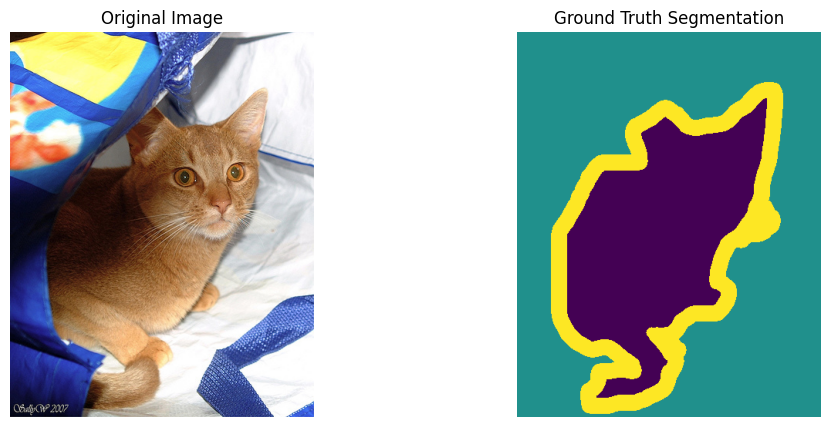

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Ground Truth Segmentation")
plt.axis("off")

plt.show()

In [10]:
mask_array = np.array(mask)

unique, counts = np.unique(mask_array, return_counts=True)

for value, count in zip(unique, counts):
    print(f"Class {value}: {count} pixels")

Class 1: 52806 pixels
Class 2: 114847 pixels
Class 3: 29347 pixels


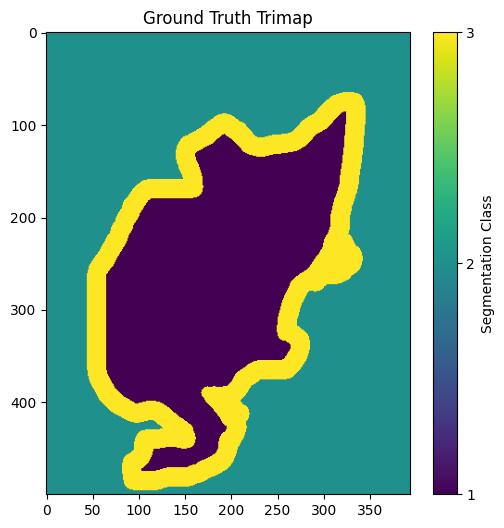

In [11]:
plt.figure(figsize=(6, 6))

plt.imshow(mask_array, cmap="viridis")
plt.colorbar(
    ticks=[1, 2, 3],
    label="Segmentation Class"
)

plt.title("Ground Truth Trimap")
plt.show()

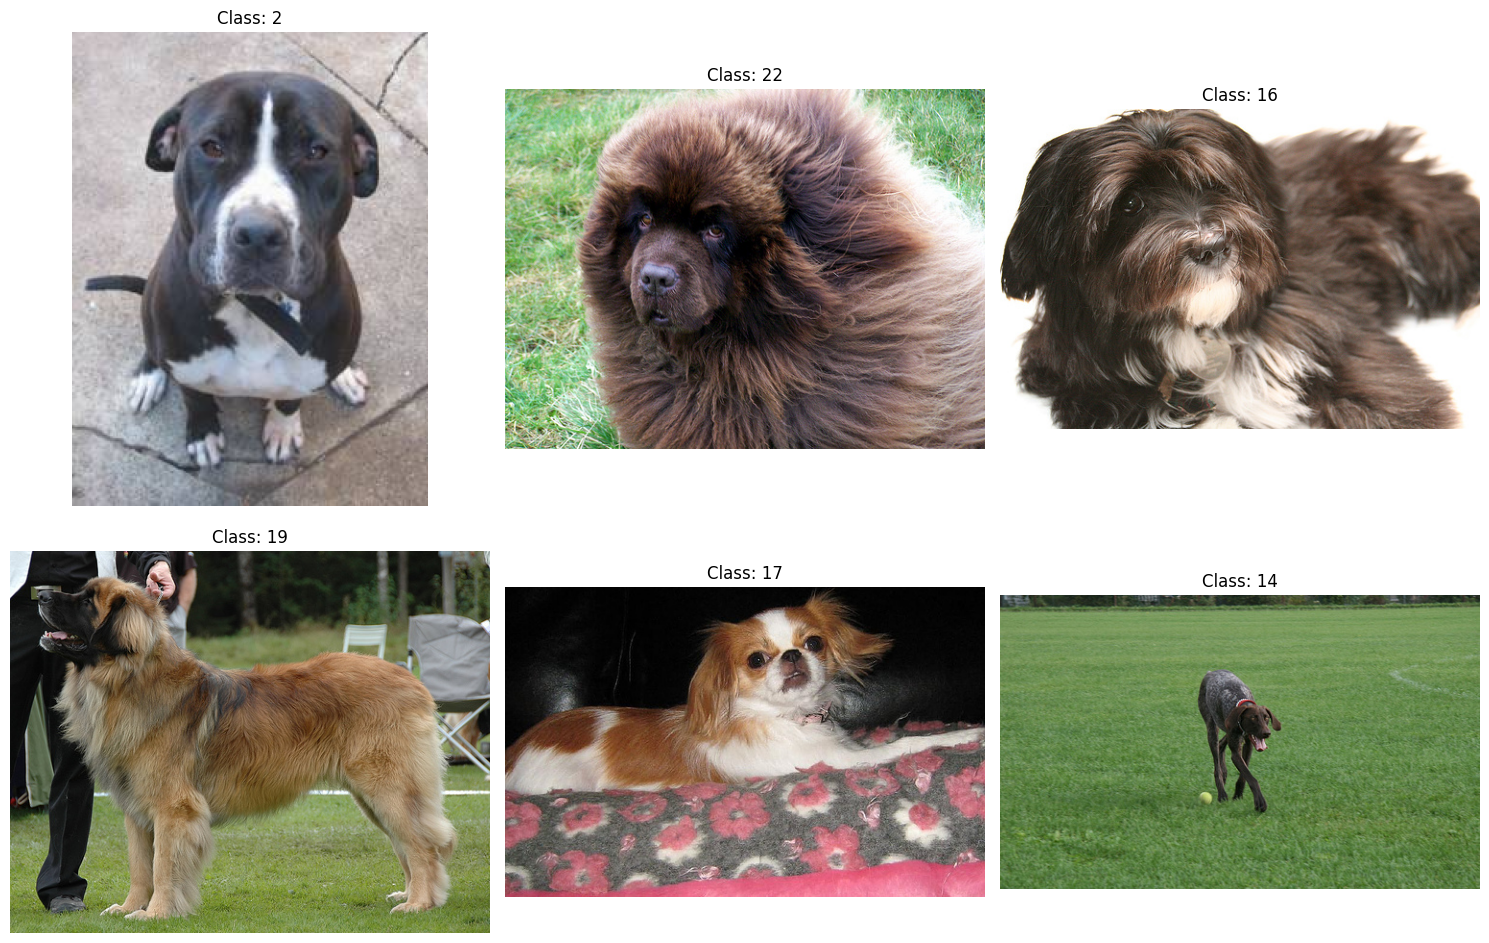

In [13]:
import random

indices = random.sample(range(len(dataset)), 6)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    image, (category, mask) = dataset[idx]

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {category}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
categories = []

for i in range(len(dataset)):
    _, (category, _) = dataset[i]
    categories.append(category)

categories = np.array(categories)

unique_classes, counts = np.unique(categories, return_counts=True)

print("Number of classes:", len(unique_classes))

for cls, count in zip(unique_classes, counts):
    print(cls, count)

Number of classes: 37
0 100
1 100
2 100
3 100
4 100
5 100
6 100
7 96
8 100
9 100
10 100
11 93
12 96
13 100
14 100
15 100
16 100
17 100
18 100
19 100
20 100
21 100
22 96
23 100
24 100
25 100
26 100
27 100
28 100
29 100
30 100
31 100
32 99
33 100
34 100
35 100
36 100


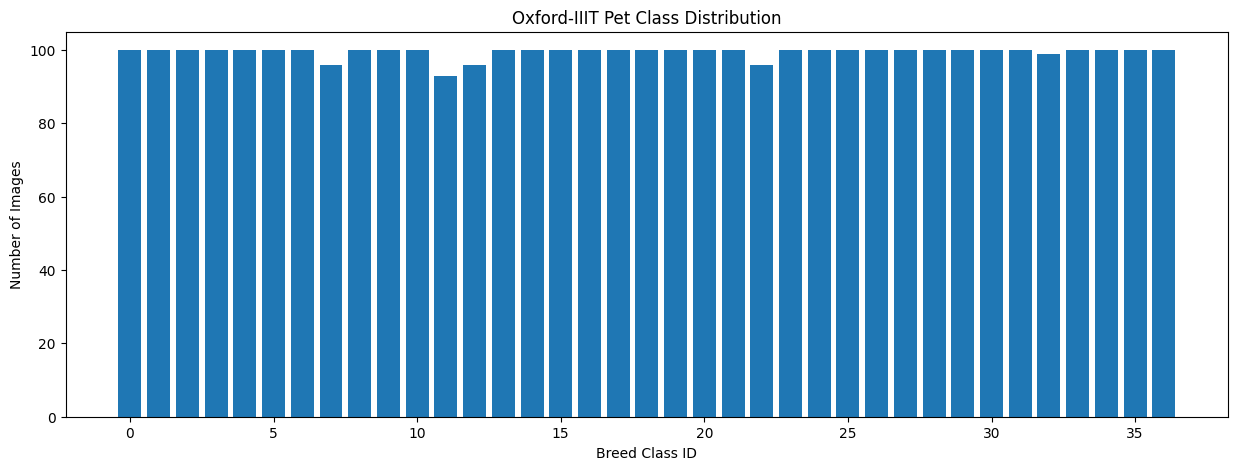

In [16]:
plt.figure(figsize=(15, 5))

plt.bar(unique_classes, counts)

plt.xlabel("Breed Class ID")
plt.ylabel("Number of Images")
plt.title("Oxford-IIIT Pet Class Distribution")

plt.show()